# Label Signal Boost Recipes

Use this notebook to rebuild stronger labels from the same candlestick images, then train on the new metadata.


In [1]:
!pip install -q yfinance transformers

In [2]:
import sys
sys.path.insert(1, '/kaggle/input/datasets/romromkankane/signal-boost')
import dataset_signal_boost

In [3]:
import sys
sys.path.insert(1, '/kaggle/input/datasets/romromkankane/signal-boost')
import kaggle_resnet_vit_boost

In [4]:
from dataset_signal_boost import *
from kaggle_resnet_vit_boost import *

## Build Stronger Binary Labels

Start here. This drops ambiguous samples and usually gives a much cleaner learning target than the original ternary setup.


In [6]:
signal_cfg = SignalConfig(
    data_root='/kaggle/input/datasets/romromkankane/stock-dataset/stock_dataset',
    output_csv='/kaggle/working/metadata_binary_1pct.csv',
    label_mode='binary_fixed',
    threshold=0.01,
    lookahead_days=1,
    purge_gap=19,
)
csv_path, summary_path = save_signal_metadata(signal_cfg)
print(csv_path)
print(summary_path)
pd.read_csv(csv_path)['label'].value_counts()

/kaggle/working/metadata_binary_1pct.csv
/kaggle/working/metadata_binary_1pct.summary.json


label
down    5701
up      4316
Name: count, dtype: int64

## Train ResNet50 On New Metadata

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 145MB/s] 
/kaggle/input/datasets/romromkankane/signal-boost/kaggle_resnet_vit_boost.py:562: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=bool(config.amp and device.type == "cuda"))
/kaggle/input/datasets/romromkankane/signal-boost/kaggle_resnet_vit_boost.py:492: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=amp_enabled):
/kaggle/input/datasets/romromkankane/signal-boost/kaggle_resnet_vit_boost.py:492: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=amp_enabled):


[01/14] train_acc=0.6453 val_acc=0.5283 train_f1=0.6450 val_f1=0.5224 lr=4.94e-05


/kaggle/input/datasets/romromkankane/signal-boost/kaggle_resnet_vit_boost.py:492: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=amp_enabled):
/kaggle/input/datasets/romromkankane/signal-boost/kaggle_resnet_vit_boost.py:492: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=amp_enabled):


[02/14] train_acc=0.8581 val_acc=0.5339 train_f1=0.8581 val_f1=0.5334 lr=4.76e-05


...

[12/14] train_acc=0.9993 val_acc=0.5633 train_f1=0.9993 val_f1=0.5392 lr=3.43e-06


/kaggle/input/datasets/romromkankane/signal-boost/kaggle_resnet_vit_boost.py:492: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=amp_enabled):
/kaggle/input/datasets/romromkankane/signal-boost/kaggle_resnet_vit_boost.py:492: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=amp_enabled):


[13/14] train_acc=1.0000 val_acc=0.5563 train_f1=1.0000 val_f1=0.5261 lr=1.61e-06
Early stopping at epoch 13


/kaggle/input/datasets/romromkankane/signal-boost/kaggle_resnet_vit_boost.py:532: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=amp_enabled):
/kaggle/input/datasets/romromkankane/signal-boost/kaggle_resnet_vit_boost.py:532: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=amp_enabled):


Saved summary to /kaggle/working/candlestick_runs/resnet50_320px_gap19_down-up_summary.json


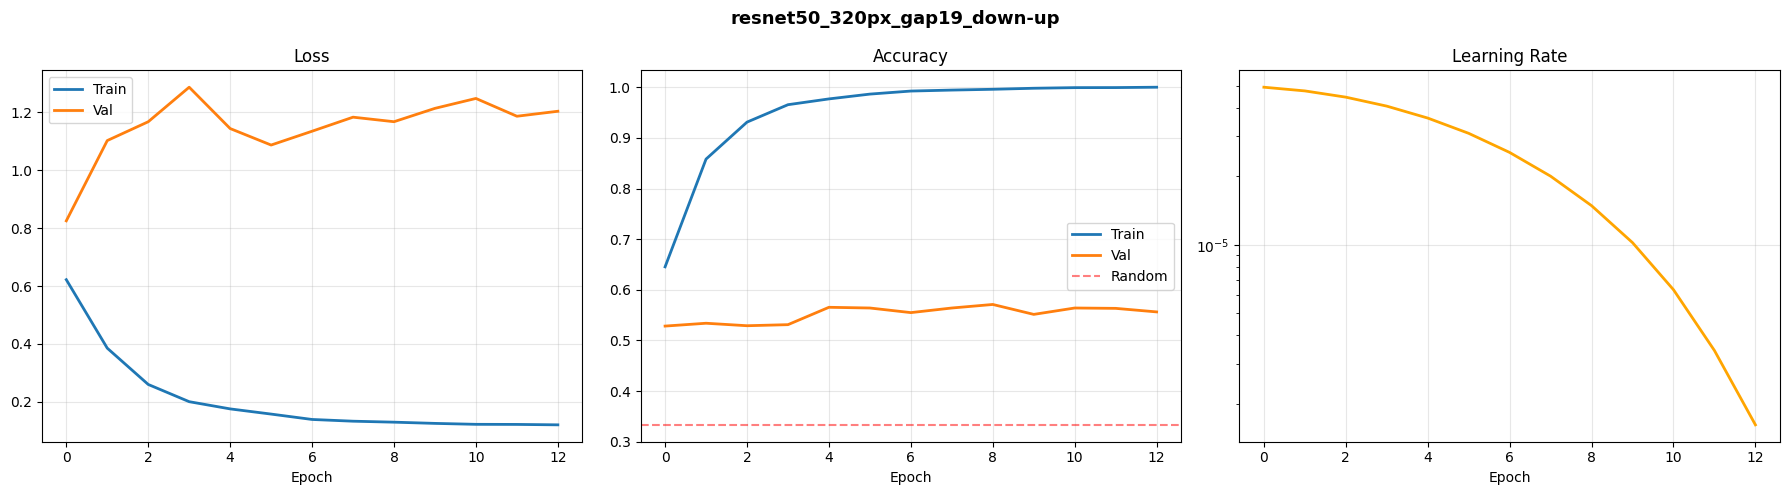

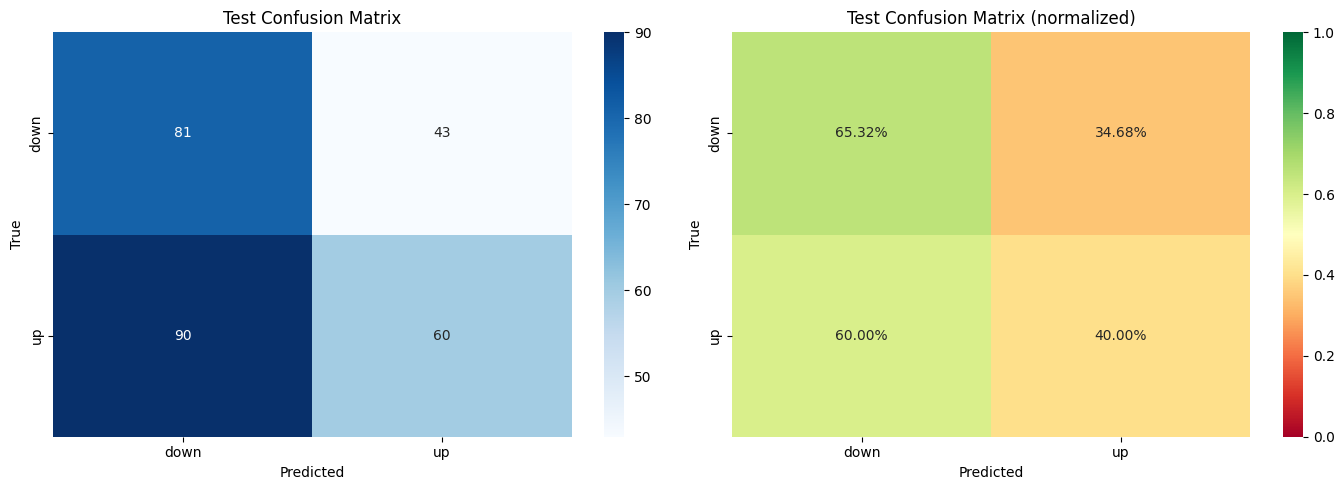

,precision,recall,f1-score,support
down,0.473684,0.653226,0.549153,124.000000
up,0.582524,0.400000,0.474308,150.000000
accuracy,0.514599,0.514599,0.514599,0.514599
macro avg,0.528104,0.526613,0.511730,274.000000
weighted avg,0.533268,0.514599,0.508179,274.000000


In [7]:
train_cfg = TrainConfig(
    data_root='/kaggle/input/stock-dataset/stock_dataset',
    metadata_csv=str(csv_path),
    model_family='resnet50',
    class_names=('down', 'up'),
    image_size=320,
    batch_size=32,
    epochs=14,
    patience=4,
    purge_gap=19,
)
report = train_model(train_cfg)
plot_history(report)
plot_confusion(report)
pd.DataFrame(report['test']['classification_report']).T

## Train DeiT On The Same Metadata

Use this after the ResNet run. If GPU memory is tight, lower `batch_size` to `8`.


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


pytorch_model.bin:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

...

[04/12] train_acc=0.9239 val_acc=0.5234 train_f1=0.9238 val_f1=0.5211 lr=2.28e-05


/kaggle/input/datasets/romromkankane/signal-boost/kaggle_resnet_vit_boost.py:492: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=amp_enabled):
/kaggle/input/datasets/romromkankane/signal-boost/kaggle_resnet_vit_boost.py:492: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=amp_enabled):


[05/12] train_acc=0.9680 val_acc=0.4871 train_f1=0.9680 val_f1=0.4531 lr=1.93e-05
Early stopping at epoch 5


/kaggle/input/datasets/romromkankane/signal-boost/kaggle_resnet_vit_boost.py:532: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=amp_enabled):
/kaggle/input/datasets/romromkankane/signal-boost/kaggle_resnet_vit_boost.py:532: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=amp_enabled):


Saved summary to /kaggle/working/candlestick_runs/deit_224px_gap19_down-up_summary.json


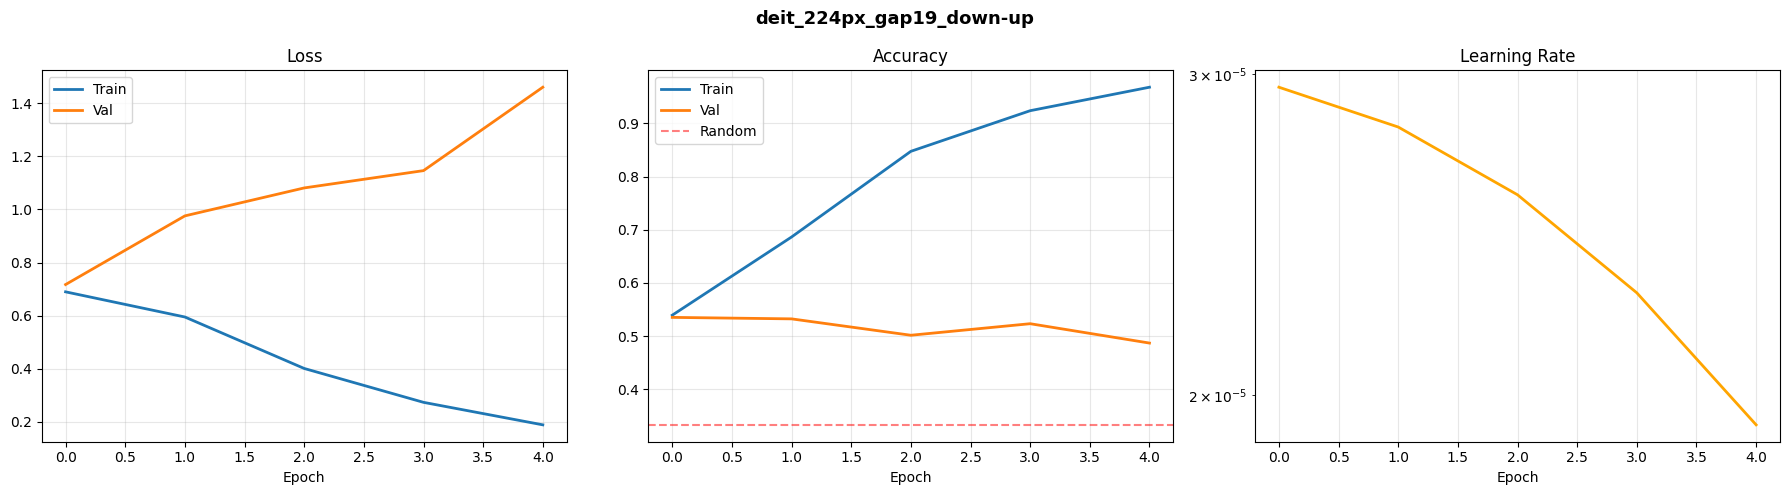

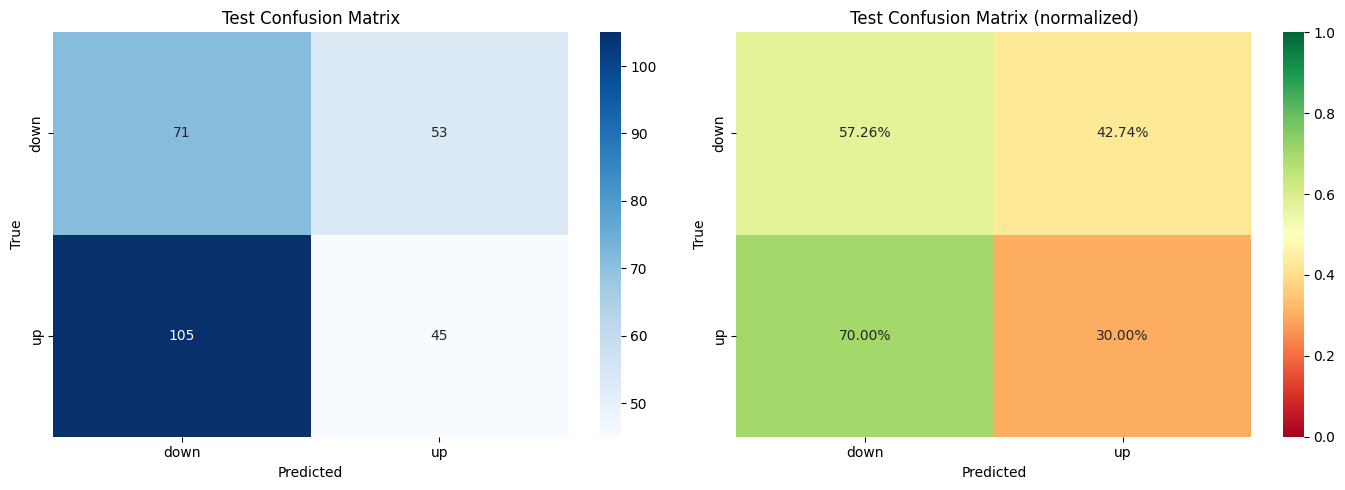

,precision,recall,f1-score,support
down,0.403409,0.572581,0.473333,124.000000
up,0.459184,0.300000,0.362903,150.000000
accuracy,0.423358,0.423358,0.423358,0.423358
macro avg,0.431296,0.436290,0.418118,274.000000
weighted avg,0.433943,0.423358,0.412879,274.000000


In [9]:
vit_cfg = TrainConfig(
    data_root='/kaggle/input/stock-dataset/stock_dataset',
    metadata_csv=str(csv_path),
    model_family='deit',
    vit_checkpoint='facebook/deit-base-patch16-224',
    class_names=('down', 'up'),
    image_size=224,
    batch_size=16,
    epochs=12,
    patience=4,
    lr_backbone=3e-5,
    lr_head=2e-4,
    purge_gap=19,
)
vit_report = train_model(vit_cfg)
plot_history(vit_report)
plot_confusion(vit_report)
pd.DataFrame(vit_report['test']['classification_report']).T

## Alternative Recipe: Quantile Labels

If `binary_fixed` still underperforms, try balanced top/bottom quantile labels.


In [ ]:
quant_cfg = SignalConfig(
    data_root='/kaggle/input/datasets/romromkankane/stock-dataset/stock_dataset',
    output_csv='/kaggle/working/metadata_binary_quantile.csv',
    label_mode='binary_quantile',
    quantile=0.35,
    lookahead_days=1,
    purge_gap=19,
)
csv_path_q, summary_path_q = save_signal_metadata(quant_cfg)
print(csv_path_q)
pd.read_csv(csv_path_q)['label'].value_counts()